In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset using the custom delimiter parameter (Page 1)
df = pd.read_csv("student-mat.csv", sep=";")

print("----- CELL 1 SUCCESS -----")
print(f"Dataset securely loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

=== CELL 1 SUCCESS ===
Dataset securely loaded with 395 rows and 33 columns.


In [17]:
print("=== STRUCTURAL INFO ===")
print(df.info())  # Evaluates shapes and types (Page 2)

print("\n=== MISSING VALUES OVERVIEW ===")
print(df.isnull().sum())  # Checks structural missing values per field (Page 2)

print("\n=== TARGET VARIABLE SUMMARY (G3) ===")
print(df["G3"].describe())  # Calculates statistical distribution parameters (Page 2)

=== STRUCTURAL INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null  

In [18]:
# Outlier tracking for 'absences' column using IQR logic (Page 10)
Q1 = df["absences"].quantile(0.25)
Q3 = df["absences"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["absences"] < lower_bound) | (df["absences"] > upper_bound)]
print(f"=== ANOMALY DETECTION REPORT ===")
print(f"Identified {len(outliers)} statistical outlier records in student absences.")
print(outliers[["school", "sex", "age", "absences", "G3"]].head())

=== ANOMALY DETECTION REPORT ===
Identified 15 statistical outlier records in student absences.
    school sex  age  absences  G3
40      GP   F   16        25  11
74      GP   F   16        54  11
103     GP   F   15        26   6
183     GP   F   17        56   8
198     GP   F   17        24  18


C:\Users\ADIYA\AppData\Local\Temp\ipykernel_33020\3922444861.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="studytime", y="G3", ax=axes[0,1], palette="Set2")


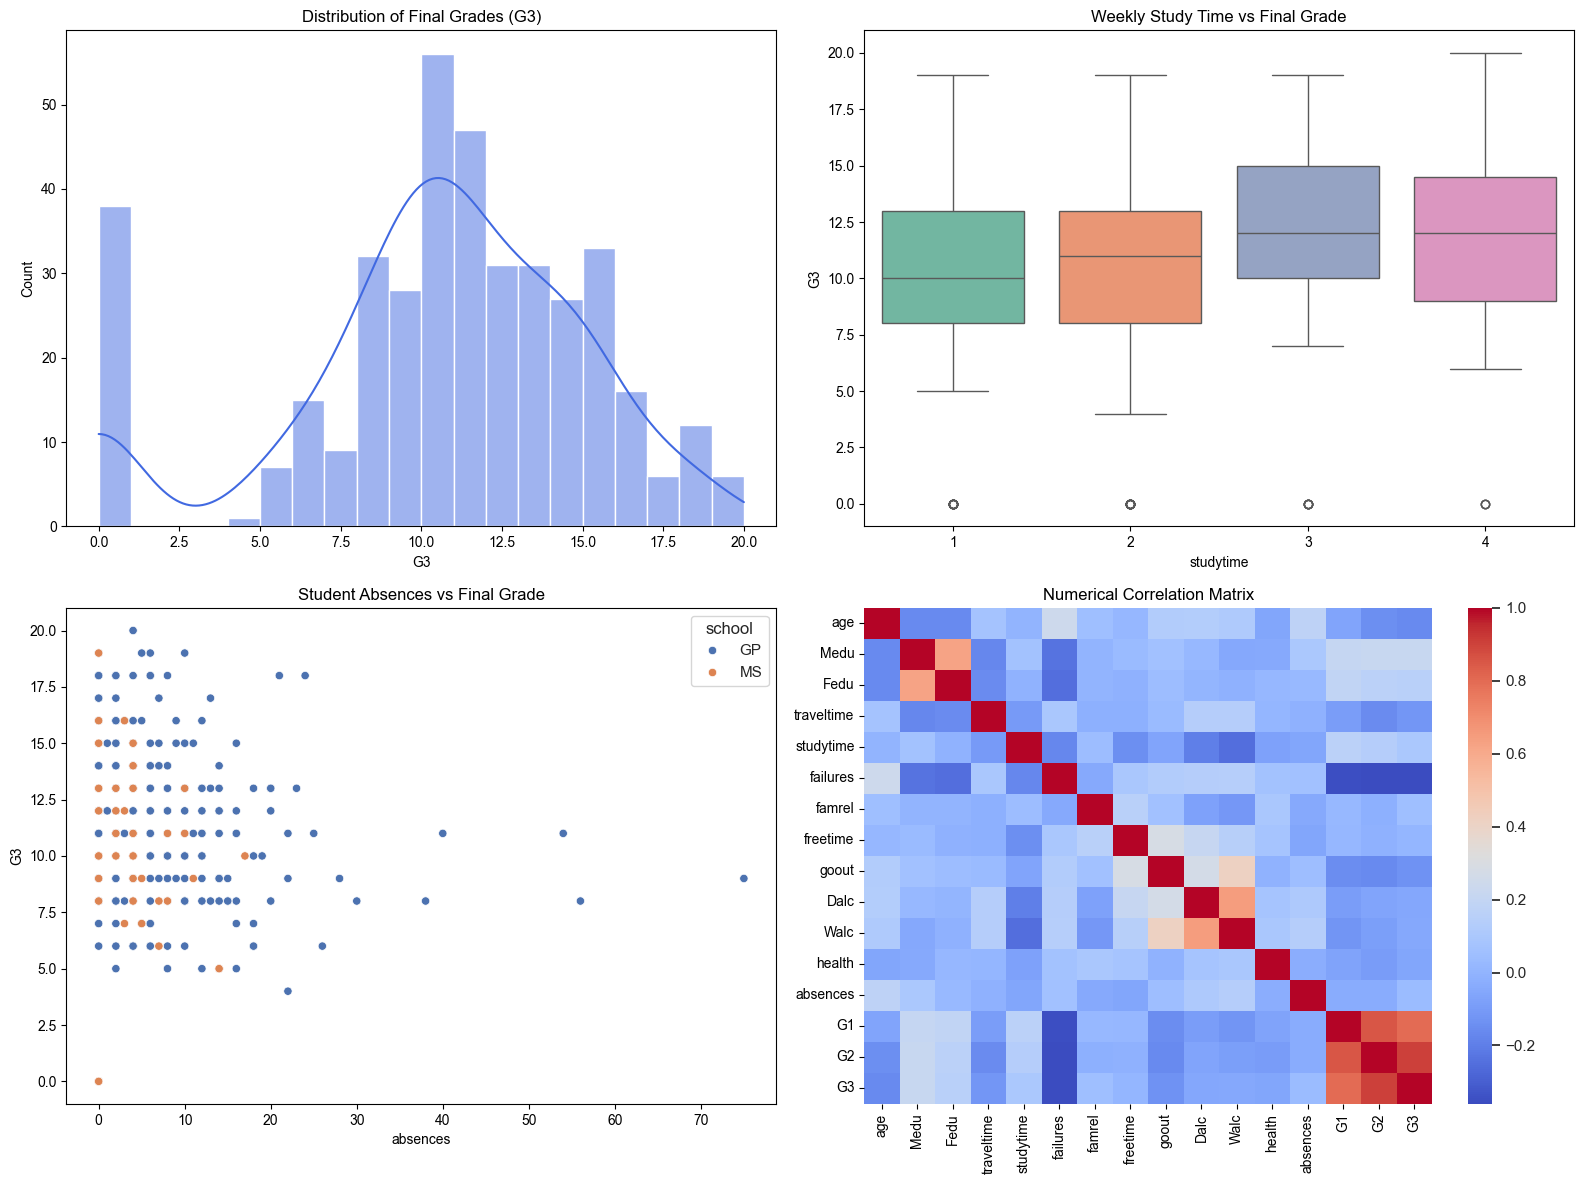

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Box 1: Target distribution
sns.histplot(data=df, x="G3", kde=True, bins=20, ax=axes[0,0], color="royalblue")
axes[0,0].set_title("Distribution of Final Grades (G3)")

# Box 2: Categorical vs Continuous breakdown
sns.boxplot(data=df, x="studytime", y="G3", ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Weekly Study Time vs Final Grade")

# Box 3: Scatter plot relationship mapping
sns.scatterplot(data=df, x="absences", y="G3", hue="school", ax=axes[1,0])
axes[1,0].set_title("Student Absences vs Final Grade")

# Box 4: Feature correlation matrix heatmap
sns.heatmap(df.select_dtypes("number").corr(), annot=False, cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Numerical Correlation Matrix")

plt.tight_layout()
plt.show()

In [20]:
# 1. Interaction Feature Creation (Page 5)
df['study_vs_free'] = df['studytime'] / (df['freetime'] + 1)

# 2. Additive Lifestyle Feature Aggregation (Page 5)
df['total_alcohol'] = df['Dalc'] + df['Walc']

# 3. Conditional Target Partitioning using NumPy Where (Page 5)
df['academic_risk'] = np.where(df['G3'] < 8, 1, 0)

# 4. Continuous Column Binning using Pandas Cut (Page 5)
df['absence_tier'] = pd.cut(df['absences'], 
                            bins=[-1, 5, 15, float('inf')], 
                            labels=['Low_Absence', 'Medium_Absence', 'High_Absence'])

# 5. Text Categorical Flag Mapping (Page 5)
df['is_urban'] = np.where(df['address'] == 'U', 1, 0)
df['wants_higher_edu'] = np.where(df['higher'] == 'yes', 1, 0)

print("=== PIPELINE STAGE 4 COMPLETE ===")
engineered_cols = ['study_vs_free', 'total_alcohol', 'academic_risk', 'absence_tier', 'is_urban', 'wants_higher_edu']
print(df[engineered_cols].head(10))

=== PIPELINE STAGE 4 COMPLETE ===
   study_vs_free  total_alcohol  academic_risk    absence_tier  is_urban  \
0       0.500000              2              1  Medium_Absence         1   
1       0.500000              2              1     Low_Absence         1   
2       0.500000              5              0  Medium_Absence         1   
3       1.000000              2              0     Low_Absence         1   
4       0.500000              3              0     Low_Absence         1   
5       0.400000              3              0  Medium_Absence         1   
6       0.400000              2              0     Low_Absence         1   
7       1.000000              2              1  Medium_Absence         1   
8       0.666667              2              0     Low_Absence         1   
9       0.333333              2              0     Low_Absence         1   

   wants_higher_edu  
0                 1  
1                 1  
2                 1  
3                 1  
4                 1